# D1. 음성 AI 첫걸음: 기술 지형도 & 개발환경 구축

**음성 AI 전문가 과정 (160h) | 1주차 M1 | 4시간**

## 학습 목표
1. 음성 AI의 4대 기술(ASR, TTS, Speech-to-Speech, Voice Agent)을 구분할 수 있다.
2. Colab GPU 환경을 점검하고 로컬 개발환경(uv) 구성 방법을 안다.
3. 글자를 소리로(TTS), 소리를 글자로(ASR) 바꾸는 과정을 직접 실행해 본다.
4. 듣고, 생각하고, 말하는 **미니 음성 비서**를 만들어 본다.

## 오늘의 실습 흐름
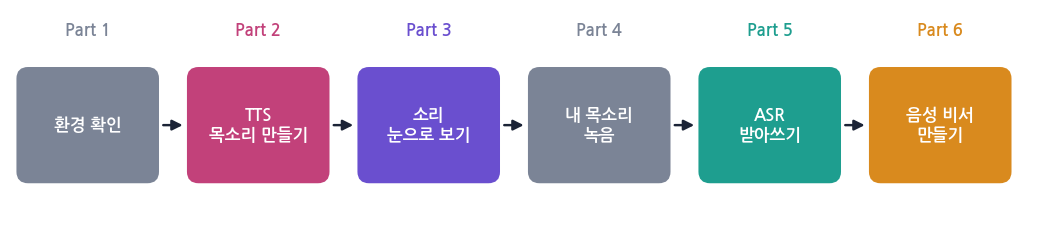

| 교시 | 내용 | 실습 |
|---|---|---|
| 1교시 | 과정 OT, 음성 AI 지형도, 기술 발전사 | HTML 애니메이션, Part 0 |
| 2교시 | 개발환경 확인, TTS, 소리 보기 | Part 1 ~ 3 |
| 3교시 | 녹음, ASR 받아쓰기, 정확도 확인 | Part 4 ~ 5 |
| 4교시 | 미니 음성 비서, 정리, 퀴즈 | Part 6 ~ 7, HTML 워크시트 |

## 오늘의 수업 자료
| 자료 | 링크 | 언제 쓰나요 |
|---|---|---|
| 🎬 인터랙티브 애니메이션 | [animation.html](https://imguru-mooc.github.io/AI_Voice/day01/animation.html) | 각 Part 설명을 볼 때 (Part마다 바로가기 링크가 있습니다) |
| 📝 이해도 확인 워크시트 | [worksheet.html](https://imguru-mooc.github.io/AI_Voice/day01/worksheet.html) | 4교시 마무리, 15문항 |

## 이 노트북 사용법
- ▶️ 일반 코드 셀은 위에서부터 차례로 실행합니다.
- 🧩 **빈칸 실습** 셀은 `____`(밑줄 4개)를 지우고 알맞은 값을 채운 뒤 실행합니다. 마지막 줄에서 ✅ 또는 ❌로 결과를 알려줍니다.
- 🔑 **정답 및 해설 보기**를 클릭하면 정답이 펼쳐집니다. 먼저 스스로 풀어 보세요.

> ⚙️ **시작 전 필수:** 메뉴 `런타임 > 런타임 유형 변경 > T4 GPU` 선택 후 저장

## Part 0. 음성 AI 4대 기술 지형도

음성 AI는 **무엇을 넣고 무엇을 얻는가**로 구분하면 쉽습니다.

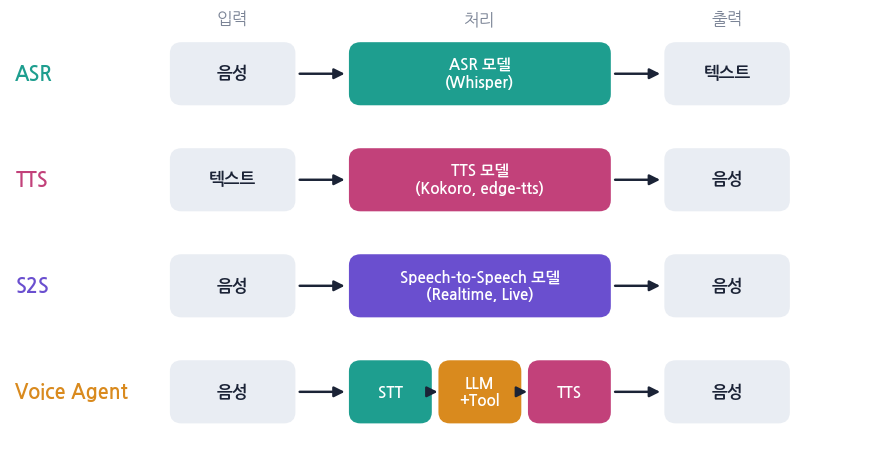

| 기술 | 한 줄 설명 | 대표 도구 | 과정 주차 |
|---|---|---|---|
| **ASR** (STT) | 소리를 듣고 **받아쓰기** | Whisper, faster-whisper | 2~3주차 |
| **TTS** | 글자를 **소리 내어 읽기** | Kokoro, Chatterbox, edge-tts | 4주차 |
| **Speech-to-Speech** | 글자를 거치지 않고 **소리로 바로 대답** | OpenAI Realtime, Gemini Live | 6주차 |
| **Voice Agent** | ASR + LLM + TTS를 이어 붙인 **음성 비서** | Pipecat, LiveKit Agents, MCP | 5~6주차 |

오늘은 이 네 가지를 **맛보기** 수준으로 모두 직접 돌려봅니다.

> 🎬 **애니메이션으로 보기:** [오늘의 흐름](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#flow) — Part 1~6 로드맵
>
> 🎬 **애니메이션으로 보기:** [4대 기술](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#tech) — 입력이 출력으로 바뀌는 과정

## Part 1. 개발환경 확인 및 설치

개발환경은 **층(Layer)**으로 쌓여 있습니다. 아래층이 맞아야 위층이 동작하므로, 오류가 나면 **아래층부터** 점검합니다.

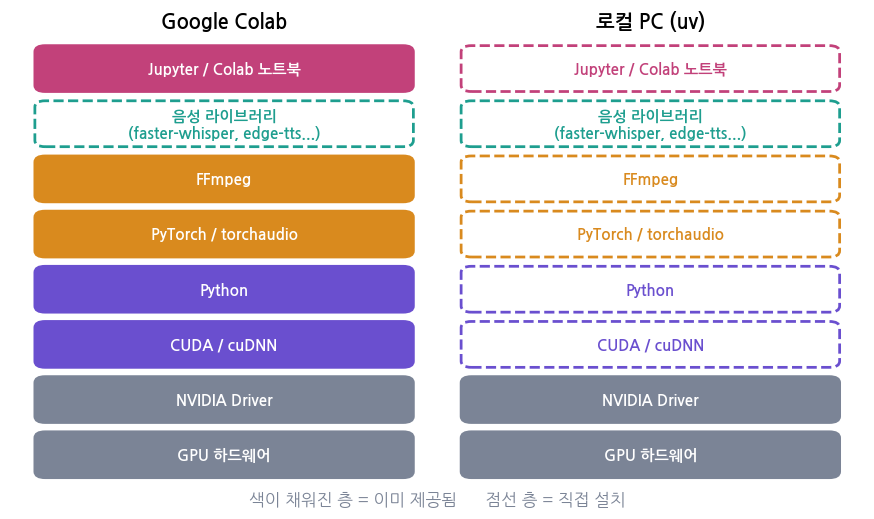

Colab은 대부분의 층이 이미 준비되어 있어서, 우리는 **맨 위 음성 라이브러리만** 설치하면 됩니다.

> 🎬 **애니메이션으로 보기:** [개발환경 층](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#stack) — Colab과 로컬 PC 비교, 층별 확인 명령

### 1-1. GPU 확인
`nvidia-smi`는 GPU 이름과 메모리 사용량을 보여줍니다.

In [ ]:
!nvidia-smi

### 1-2. Python / PyTorch / CUDA / FFmpeg 점검

In [ ]:
import sys, shutil, subprocess
import torch

print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"CUDA 사용   : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"GPU 메모리  : {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    print(f"CUDA(Torch) : {torch.version.cuda}")
    print(f"cuDNN       : {torch.backends.cudnn.version()}")
ffmpeg = shutil.which("ffmpeg")
print(f"FFmpeg      : {ffmpeg if ffmpeg else '❌ 없음'}")

### 1-3. 실습 패키지 설치
- `faster-whisper`: CTranslate2 기반 고속 Whisper 추론 (ASR)
- `edge-tts`: Microsoft Edge 온라인 Neural TTS (한국어 음성 지원, 인터넷 필요)
- `anthropic`: Claude API SDK (LLM)
- `jiwer`: WER/CER 평가

In [ ]:
!pip install -q faster-whisper edge-tts anthropic jiwer librosa soundfile
print("✅ 설치 완료")

### 1-4. 빈칸 실습 준비
아래 셀을 먼저 실행하세요. 🧩 빈칸 실습에서 정답 여부를 알려주는 도우미입니다.

In [ ]:
# ▶️ 빈칸 실습 채점 도우미 (먼저 실행)
def check(cond, hint="빈칸을 다시 확인하세요."):
    print("✅ 정답입니다! 🎉" if cond else f"❌ {hint}")

print("🧩 빈칸 실습 준비 완료")

### 🧩 빈칸 실습 1: GPU를 쓸 수 있는지 확인하기
위 1-2 셀의 코드를 참고하세요.

In [ ]:
# 🧩 빈칸 실습 1
gpu_ok = torch.cuda.____()          # 힌트: "사용 가능한가요?" → is_...

print("GPU 사용 가능!" if gpu_ok else "GPU 없음 (런타임 유형을 확인하세요)")
check(gpu_ok == torch.cuda.is_available(), hint="1-2 셀에서 같은 함수를 찾아보세요.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
gpu_ok = torch.cuda.is_available()
```

**해설**: `torch.cuda.is_available()`은 PyTorch가 GPU를 쓸 수 있으면 `True`를 돌려줍니다. Colab에서 `False`가 나오면 메뉴의 `런타임 > 런타임 유형 변경`에서 GPU를 선택했는지 확인하세요.

</details>

### 1-4. (참고) 로컬 PC 개발환경: `uv`
`uv`는 Rust로 작성된 매우 빠른 Python 패키지·프로젝트 관리 도구입니다. pip + venv + pyenv 역할을 한 번에 합니다.
아래 명령은 **로컬 터미널**에서 실행합니다 (Colab 셀 아님).

```bash
# 설치 (macOS / Linux)
curl -LsSf https://astral.sh/uv/install.sh | sh
# 설치 (Windows PowerShell)
powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"

# 프로젝트 생성
uv init voice-ai && cd voice-ai
uv python pin 3.11
uv add torch torchaudio librosa soundfile faster-whisper edge-tts anthropic jiwer jupyterlab

# 실행
uv run jupyter lab
```
> 💡 로컬 GPU를 쓰려면 NVIDIA Driver와 PyTorch CUDA 빌드가 맞아야 합니다. 설치 후 `uv run python -c "import torch; print(torch.cuda.is_available())"`로 확인하세요.

## Part 2. TTS 맛보기: 글자 → 소리

### 오늘 소리 파일이 흘러가는 길
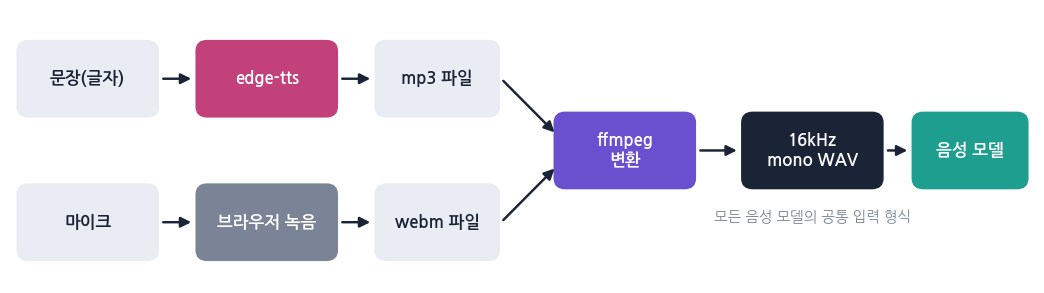

- TTS가 만든 **mp3**, 브라우저가 녹음한 **webm**은 형식이 제각각입니다.
- 그래서 `ffmpeg`로 **16kHz mono WAV**라는 공통 형식으로 바꾼 뒤 음성 모델에 넣습니다.
- 16kHz는 1초에 16,000번 소리를 측정했다는 뜻이고, mono는 채널이 하나라는 뜻입니다.

> 🎬 **애니메이션으로 보기:** [소리 파일의 여행](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#file) — mp3, webm이 16kHz WAV가 되기까지

먼저 사용할 수 있는 한국어 목소리 목록을 확인합니다.

In [ ]:
import edge_tts

voices = await edge_tts.list_voices()
ko_voices = [v for v in voices if v["Locale"].startswith("ko-")]
for v in ko_voices:
    print(f'{v["ShortName"]:28s} {v["Gender"]}')

In [ ]:
import subprocess
from IPython.display import Audio, display

def to_wav16k(src: str, dst: str) -> str:
    # 모든 음성 모델 입력 표준에 맞춰 16kHz, mono WAV로 변환
    subprocess.run(["ffmpeg", "-y", "-loglevel", "error", "-i", src,
                    "-ar", "16000", "-ac", "1", dst], check=True)
    return dst

async def tts(text: str, out_wav: str = "tts.wav",
              voice: str = "ko-KR-SunHiNeural", rate: str = "+0%") -> str:
    mp3 = out_wav.rsplit(".", 1)[0] + ".mp3"
    await edge_tts.Communicate(text, voice, rate=rate).save(mp3)
    return to_wav16k(mp3, out_wav)

SAMPLE_TEXT = "안녕하세요. 음성 AI 전문가 과정에 오신 것을 환영합니다. 오늘은 음성 인식과 음성 합성을 직접 체험해 봅니다."
wav = await tts(SAMPLE_TEXT, "sample.wav")
display(Audio(wav))

### 🧪 실습 2-1: 목소리와 속도 바꿔보기
`voice`를 `ko-KR-InJoonNeural`로, `rate`를 `"+30%"`, `"-20%"`로 바꿔 비교해 보세요.

In [ ]:
for voice, rate in [("ko-KR-InJoonNeural", "+0%"), ("ko-KR-SunHiNeural", "+30%"), ("ko-KR-SunHiNeural", "-20%")]:
    out = await tts("오늘 날씨가 참 좋네요.", f"tts_{voice}_{rate}.wav", voice=voice, rate=rate)
    print(voice, rate)
    display(Audio(out))

### 🧩 빈칸 실습 2: 내 문장을 남자 목소리로 읽히기
① 읽히고 싶은 문장을 자유롭게 쓰고, ② 위 목록에서 **Male** 목소리 이름을 골라 채우세요.

In [ ]:
# 🧩 빈칸 실습 2
my_text  = "____"            # ① 읽히고 싶은 문장
my_voice = "____"            # ② 남성 목소리 이름 (위 목록에서 Male인 것)

out_wav = await tts(my_text, "my_tts.wav", voice=my_voice)
display(Audio(out_wav))

male = [v["ShortName"] for v in ko_voices if v["Gender"] == "Male"]
check(not my_text.startswith("_") and my_voice in male, hint=f"남성 목소리 이름: {male}")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
my_text  = "오늘부터 음성 AI를 배웁니다."
my_voice = "ko-KR-InJoonNeural"
```

**해설**: 문장은 자유입니다. 목소리는 목록에서 `Male`로 표시된 이름(예: `ko-KR-InJoonNeural`)을 **정확히** 써야 합니다. 이름이 틀리면 edge-tts가 오류를 냅니다.

</details>

## Part 3. 소리 눈으로 보기: 파형과 스펙트로그램

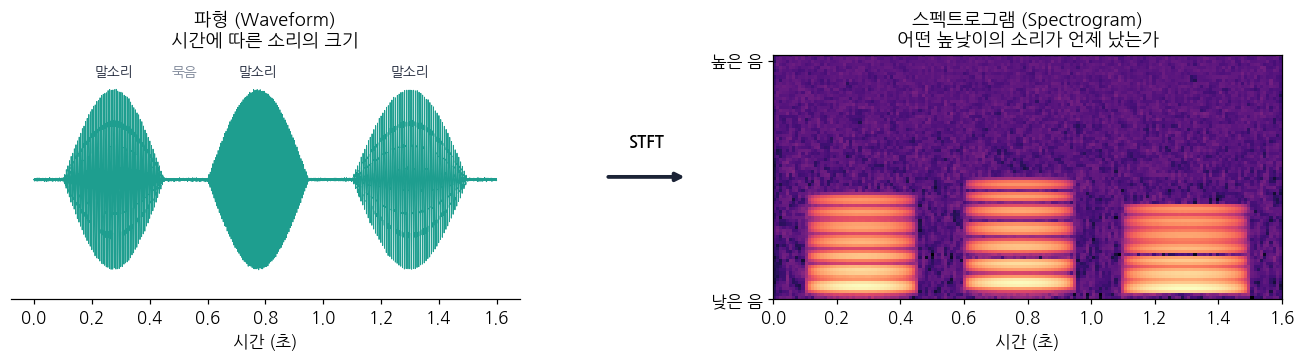

| 그림 | 보이는 것 | 읽는 법 |
|---|---|---|
| **파형** (Waveform) | 시간에 따른 소리의 크기 | 위아래로 크게 흔들리면 큰 소리, 평평하면 묵음 |
| **스펙트로그램** (Spectrogram) | 언제, 어떤 높낮이의 소리가 났는가 | 밝을수록 그 높이의 소리가 강함 |

- 파형을 짧게 잘라 높낮이별로 분해하면(STFT) 스펙트로그램이 됩니다. 원리는 D3에서 배웁니다.
- **Whisper는 소리를 이 스펙트로그램 "그림"으로 바꿔서 읽습니다.**

> 🎬 **애니메이션으로 보기:** [샘플링 체험](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#sampling) — 측정 횟수를 바꿔 보고, 8k/16k/44.1kHz 소리 비교 듣기
>
> 🎬 **애니메이션으로 보기:** [내 목소리 보기](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#mic) — 마이크로 실시간 파형과 스펙트로그램

In [ ]:
import numpy as np
import librosa, librosa.display
import matplotlib.pyplot as plt

def show_audio(path: str, title: str = ""):
    y, sr = librosa.load(path, sr=16000)
    print(f"샘플 수: {len(y):,} | 샘플링 레이트: {sr} Hz | 길이: {len(y)/sr:.2f}초 | 범위: [{y.min():.3f}, {y.max():.3f}]")
    fig, ax = plt.subplots(2, 1, figsize=(12, 6))
    librosa.display.waveshow(y, sr=sr, ax=ax[0], color="#1E9E8F")
    ax[0].set_title(f"Waveform {title}")
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=400, hop_length=160, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, hop_length=160, x_axis="time", y_axis="mel", ax=ax[1])
    fig.colorbar(img, ax=ax[1], format="%+2.0f dB")
    ax[1].set_title("Log-Mel Spectrogram (80 mels, 25ms window, 10ms hop)")
    plt.tight_layout(); plt.show()
    return y, sr

y, sr = show_audio("sample.wav", "(TTS sample)")

> ❓ **생각해 보기:** 파형에서 평평한 구간(묵음)은 스펙트로그램에서 어떻게 보이나요?
>
> 모든 높이에서 어둡게 보입니다. 이런 묵음 구간을 자동으로 찾는 기술이 **VAD**(Voice Activity Detection)이고, Part 5의 `vad_filter=True`가 바로 이 기능입니다.

### 🧩 빈칸 실습 3: 오디오 길이 구하기
위 출력의 **샘플 수**는 소리를 측정한 횟수입니다. 1초에 16,000번 측정했다면 길이는 몇 초일까요?

In [ ]:
# 🧩 빈칸 실습 3  (위 셀에서 만든 y, sr 사용)
seconds = len(y) / ____           # 힌트: 1초당 측정 횟수 = 샘플링 레이트

print(f"샘플 {len(y):,}개 ÷ 1초에 {sr:,}개 = {seconds:.2f}초")
check(abs(seconds - len(y) / 16000) < 1e-9, hint="1초에 16,000개씩 측정했습니다. 변수 sr을 써도 됩니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
seconds = len(y) / sr        # 또는 len(y) / 16000
```

**해설**: 길이(초) = 샘플 수 ÷ 1초당 샘플 수. 예를 들어 샘플이 80,000개면 80,000 ÷ 16,000 = 5초입니다.

</details>

## Part 4. 내 목소리 녹음하기 (Colab 브라우저 마이크)

실행하면 브라우저가 마이크 권한을 요청합니다. **허용** 후 말씀하세요.
마이크가 없다면 이 Part는 건너뛰고 `sample.wav`를 사용합니다.

> 🎬 **애니메이션으로 보기:** [내 목소리 보기](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#mic) — 녹음 전에 마이크가 소리를 잘 받는지 실시간으로 확인

In [ ]:
from base64 import b64decode
from IPython.display import Javascript
from google.colab.output import eval_js

RECORD_JS = '''
const sleep = t => new Promise(r => setTimeout(r, t));
const blobToDataURL = blob => new Promise(resolve => {
  const reader = new FileReader();
  reader.onloadend = () => resolve(reader.result);
  reader.readAsDataURL(blob);
});
var record = async (sec) => {
  const stream = await navigator.mediaDevices.getUserMedia({audio: true});
  const recorder = new MediaRecorder(stream);
  const chunks = [];
  recorder.ondataavailable = e => chunks.push(e.data);
  const stopped = new Promise(r => recorder.onstop = r);
  recorder.start();
  await sleep(sec * 1000);
  recorder.stop();
  await stopped;
  stream.getTracks().forEach(t => t.stop());
  return await blobToDataURL(new Blob(chunks));
};
'''

def record_audio(seconds: int = 5, filename: str = "my_voice.wav") -> str:
    display(Javascript(RECORD_JS))
    print(f"🎙️ {seconds}초간 녹음합니다. 지금 말씀하세요...")
    data_url = eval_js(f"record({seconds})")
    with open("tmp_record.webm", "wb") as f:
        f.write(b64decode(data_url.split(",")[1]))
    to_wav16k("tmp_record.webm", filename)
    print(f"✅ 저장 완료: {filename}")
    return filename

try:
    my_wav = record_audio(5)
    display(Audio(my_wav))
    show_audio(my_wav, "(my voice)")
except Exception as e:
    print("⚠️ 녹음 실패, sample.wav로 대체합니다:", e)
    my_wav = "sample.wav"

## Part 5. ASR 맛보기: 소리 → 글자 (faster-whisper)

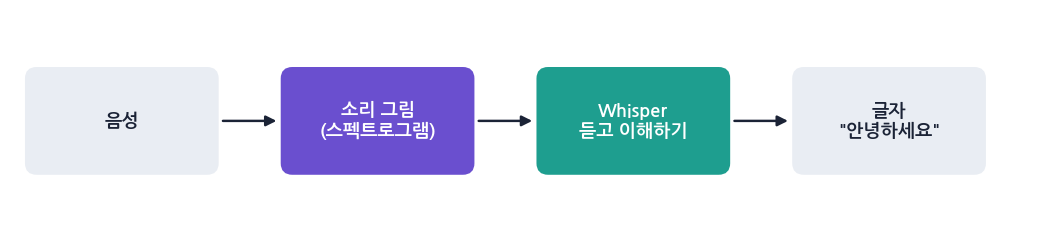

- **Whisper**는 OpenAI가 공개한 음성 인식 모델로, 한국어를 포함해 여러 언어를 받아씁니다.
- **faster-whisper**는 같은 Whisper를 더 빠르고 가볍게 실행해 주는 도구입니다.
- GPU가 있으면 `large-v3-turbo`(정확하고 빠름), 없으면 `small`(가벼움)을 자동으로 고릅니다.

**RTF**(Real-Time Factor)는 "음성 길이 대비 처리 시간"입니다. 10초 음성을 1초 만에 받아쓰면 RTF는 0.1이고, **1보다 작으면 실시간보다 빠르다**는 뜻입니다.

> 🎬 **애니메이션으로 보기:** [받아쓰기와 RTF](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#asr) — Whisper 4단계와 RTF 슬라이더

> ⚠️ **Colab 호환성 메모**: 아래 첫 두 셀은 Colab 환경에서 faster-whisper가 GPU를 쓰도록 필요한 라이브러리를 맞춰 주는 셀입니다. 내용은 몰라도 괜찮으니 그대로 실행하세요.

In [ ]:
!pip install -q nvidia-cublas-cu12 "nvidia-cudnn-cu12==9.*"

In [ ]:
import os, sys, glob, ctypes, time
import numpy as np
from faster_whisper import WhisperModel

def preload_cuda12_libs():
    """CTranslate2(CUDA 12 빌드)가 찾는 cuBLAS/cuDNN을 pip 패키지 경로에서 미리 로드.
    런타임 재시작 없이 libcublas.so.12 not found 오류를 해결합니다."""
    patterns = ["nvidia/cublas/lib/libcublasLt.so.12",
                "nvidia/cublas/lib/libcublas.so.12",
                "nvidia/cudnn/lib/libcudnn*.so.9"]
    pending = []
    for sp in sys.path:
        for pat in patterns:
            pending += sorted(glob.glob(os.path.join(sp, pat)))
    pending = list(dict.fromkeys(pending))
    loaded = []
    for _ in range(5):                       # 라이브러리 간 의존 순서 문제 → 여러 번 재시도
        for lib in pending[:]:
            try:
                ctypes.CDLL(lib, mode=ctypes.RTLD_GLOBAL)
                loaded.append(os.path.basename(lib)); pending.remove(lib)
            except OSError:
                pass
        if not pending:
            break
    print(f"🔧 CUDA 12 라이브러리 로드: {len(loaded)}개" + (f" (실패 {len(pending)}개)" if pending else ""))

def load_asr(size, device, compute_type):
    m = WhisperModel(size, device=device, compute_type=compute_type)
    segs, _ = m.transcribe(np.zeros(16000, dtype=np.float32), language="ko")
    list(segs)                                # warm-up: 실제 GPU 연산이 되는지 여기서 확인
    return m

t0 = time.perf_counter()
asr_model = None
if torch.cuda.is_available():
    preload_cuda12_libs()
    try:
        DEVICE, COMPUTE_TYPE, MODEL_SIZE = "cuda", "float16", "large-v3-turbo"
        asr_model = load_asr(MODEL_SIZE, DEVICE, COMPUTE_TYPE)
    except Exception as e:
        print(f"⚠️ GPU 로드 실패 → CPU로 전환: {e}")
if asr_model is None:
    DEVICE, COMPUTE_TYPE, MODEL_SIZE = "cpu", "int8", "small"
    asr_model = load_asr(MODEL_SIZE, DEVICE, COMPUTE_TYPE)

print(f"✅ {MODEL_SIZE} 로드 완료 ({DEVICE}, {COMPUTE_TYPE}) | {time.perf_counter()-t0:.1f}초")

In [ ]:
def load_16k(path: str) -> np.ndarray:
    # PyAV 버전 충돌을 피하기 위해 librosa로 직접 16kHz mono float32 배열로 로드
    y, _ = librosa.load(path, sr=16000, mono=True)
    return y.astype(np.float32)

def transcribe(path: str, language: str = "ko"):
    audio = load_16k(path)             # 파일 경로 대신 numpy 배열 전달
    t0 = time.perf_counter()
    segments, info = asr_model.transcribe(audio, language=language, beam_size=5, vad_filter=True)
    segments = list(segments)          # generator → 실제 추론은 여기서 실행됨
    elapsed = time.perf_counter() - t0
    text = " ".join(s.text.strip() for s in segments)
    return text, segments, info, elapsed

for path in ["sample.wav", my_wav]:
    text, segs, info, elapsed = transcribe(path)
    print(f"\n📄 {path}")
    for s in segs:
        print(f"  [{s.start:6.2f}s → {s.end:6.2f}s] {s.text.strip()}")
    print(f"  ⏱️ 처리 {elapsed:.2f}s | 오디오 {info.duration:.2f}s | RTF {elapsed/info.duration:.3f}")

### 🧩 빈칸 실습 4: 내 목소리 받아쓰기
위에서 만든 **받아쓰기 함수 이름**을 채워 Part 4에서 녹음한 내 목소리(`my_wav`)를 인식해 보세요.

In [ ]:
# 🧩 빈칸 실습 4
text, segs, info, elapsed = ____(my_wav)      # 힌트: 위 셀에서 def로 만든 함수

print(f"📄 인식 결과: {text}")
print(f"⏱️ {info.duration:.1f}초 음성을 {elapsed:.2f}초 만에 처리 (RTF {elapsed / info.duration:.2f})")
check(info.duration > 0, hint="함수 이름은 '받아쓰다'라는 뜻의 영어 단어입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
text, segs, info, elapsed = transcribe(my_wav)
```

**해설**: `transcribe()`는 인식된 글자, 구간별 결과, 오디오 정보, 처리 시간 4가지를 돌려줍니다. 녹음이 비어 있으면 인식 결과가 빈칸으로 나올 수 있으니, 그럴 땐 `my_wav` 대신 `"sample.wav"`로 바꿔 보세요.

</details>

### 5-1. 얼마나 정확할까? 틀린 글자 비율(CER)

TTS로 만든 음성은 **정답 문장을 이미 알고 있으므로**, 받아쓰기 결과와 비교하면 정확도를 바로 알 수 있습니다.

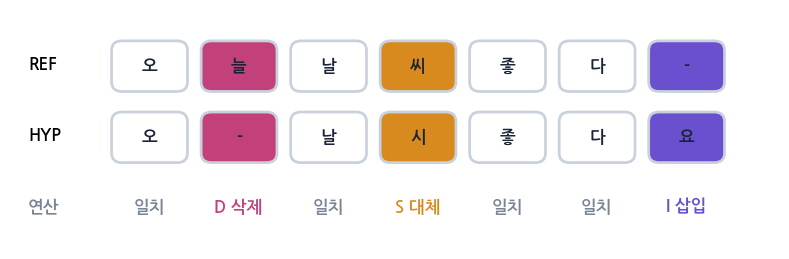

틀리는 방법은 세 가지입니다: 다른 글자로 **바뀌거나**(대체), **빠지거나**(삭제), 없는 글자가 **끼어들거나**(삽입).

**CER**(Character Error Rate)은 정답 글자 수 중에서 이렇게 틀린 글자가 몇 개인지의 비율입니다. 위 예시는 정답 6글자 중 3번 틀렸으니 **50%**입니다. 낮을수록 좋습니다.

> 한국어는 띄어쓰기가 자주 달라지기 때문에, 비교하기 전에 띄어쓰기와 문장부호를 지우고 **글자 단위**로 비교합니다.

> 🎬 **애니메이션으로 보기:** [CER 계산기](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#cer) — 직접 입력해 대체, 삭제, 삽입 확인하기

In [ ]:
import re, jiwer

def normalize_ko(s: str) -> str:
    s = re.sub(r"[^\w\s]", "", s)       # 문장부호 제거
    return re.sub(r"\s+", "", s)        # 공백 제거 (띄어쓰기 영향 배제)

hyp, _, _, _ = transcribe("sample.wav")
print("정답(REF):", SAMPLE_TEXT)
print("인식(HYP):", hyp)
print(f"CER: {jiwer.cer(normalize_ko(SAMPLE_TEXT), normalize_ko(hyp)):.2%}")

### 🧩 빈칸 실습 5: CER 직접 계산해 보기
위 그림의 예시를 코드로 확인합니다. jiwer 라이브러리에서 CER을 계산하는 함수 이름을 채우세요.

In [ ]:
# 🧩 빈칸 실습 5
ref = "오늘날씨좋다"            # 정답
hyp = "오날시좋다요"            # 인식 결과

cer = jiwer.____(ref, hyp)      # 힌트: Character Error Rate의 약자 (소문자)

print(f"CER = {cer:.0%}")
check(abs(cer - 0.5) < 1e-9, hint="위 5-1 코드 셀에서 jiwer.???(...)를 찾아보세요.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
cer = jiwer.cer(ref, hyp)
```

**해설**: 정답 6글자 중 `늘` 삭제, `씨→시` 대체, `요` 삽입으로 3번 틀렸으므로 3 ÷ 6 = **50%**입니다. 단어 단위로 비교하는 `jiwer.wer()`도 있지만, 한국어에는 `cer`이 더 적합합니다.

</details>

### 🧪 실습 5-2
1. 어려운 문장(전문용어, 숫자, 영어 혼용)을 TTS로 만들어 CER을 측정해 보세요. 예: `"GPU 메모리가 16GB인 RTX 4080에서 PyTorch 2.5를 설치했습니다."`
2. `rate="+50%"`로 빠르게 말한 음성의 CER은 어떻게 변하나요?

In [ ]:
HARD_TEXT = "GPU 메모리가 16GB인 RTX 4080에서 PyTorch 2.5를 설치했습니다."
for rate in ["+0%", "+50%"]:
    p = await tts(HARD_TEXT, f"hard_{rate}.wav", rate=rate)
    hyp, _, _, _ = transcribe(p)
    print(f"[{rate}] HYP: {hyp}\n        CER: {jiwer.cer(normalize_ko(HARD_TEXT), normalize_ko(hyp)):.2%}")

## Part 6. 미니 음성 비서 만들기: 듣고 → 생각하고 → 말하기

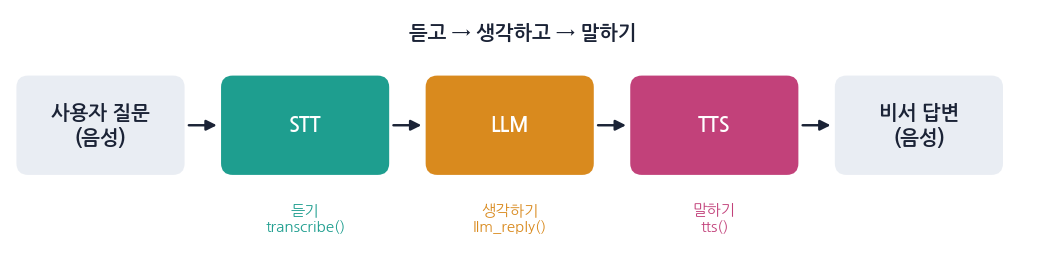

지금까지 만든 부품을 이어 붙이면 음성 비서가 됩니다.

| 단계 | 하는 일 | 오늘 만든 함수 |
|---|---|---|
| STT (듣기) | 사용자 음성을 글자로 | `transcribe()` |
| LLM (생각하기) | 질문에 대한 답변 만들기 | `llm_reply()` |
| TTS (말하기) | 답변을 음성으로 | `tts()` |

**음성 비서용 답변은 짧은 말투로**: 답변이 소리로 읽히기 때문에 표, 목록, 이모지 같은 기호는 빼고 1~2문장으로 짧게 말하도록 LLM에게 지시합니다(`SYSTEM_PROMPT`).

> 🎬 **애니메이션으로 보기:** [음성 비서 시뮬레이터](https://imguru-mooc.github.io/AI_Voice/day01/animation.html#agent) — 질문하면 듣기 → 생각하기 → 말하기, Streaming 비교

### 6-1. Claude API 키 설정 (선택)
Colab 왼쪽 🔑 **Secrets** 메뉴에 `ANTHROPIC_API_KEY`를 추가하고 노트북 액세스를 켭니다.
키가 없으면 **규칙 기반 응답**으로 자동 대체되어 실습은 그대로 진행됩니다.

In [ ]:
import os
try:
    from google.colab import userdata
    os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")
    print("✅ ANTHROPIC_API_KEY 로드 완료")
except Exception as e:
    print("⚠️ API 키 없음 → 규칙 기반 응답 사용:", type(e).__name__)

In [ ]:
from datetime import datetime, timezone, timedelta

LLM_MODEL = "claude-haiku-4-5-20251001"   # 빠른 응답용 경량 모델
SYSTEM_PROMPT = (
    "당신은 친절한 한국어 음성 비서입니다. 답변은 TTS로 읽히므로 "
    "마크다운, 목록, 이모지, 괄호를 쓰지 말고 1~2문장의 짧은 구어체로 답하세요."
)

def rule_based_reply(text: str) -> str:
    kst = datetime.now(timezone(timedelta(hours=9)))
    if "시" in text and ("몇" in text or "시간" in text):
        return f"지금은 {kst.hour}시 {kst.minute}분입니다."
    if "이름" in text:
        return "저는 음성 AI 과정 실습용 비서입니다."
    if "날씨" in text:
        return "저는 아직 날씨 정보를 조회할 수 없어요. 5주차에 도구 연결을 배우면 가능해집니다."
    return f"'{text}'라고 말씀하셨네요. 잘 들었습니다."

def llm_reply(user_text: str):
    t0 = time.perf_counter()
    if os.environ.get("ANTHROPIC_API_KEY"):
        import anthropic
        client = anthropic.Anthropic()
        msg = client.messages.create(
            model=LLM_MODEL, max_tokens=200, system=SYSTEM_PROMPT,
            messages=[{"role": "user", "content": user_text}],
        )
        reply = "".join(b.text for b in msg.content if b.type == "text")
    else:
        reply = rule_based_reply(user_text)
    return reply, time.perf_counter() - t0

### 6-2. 음성 비서 실행 & 단계별 시간 측정

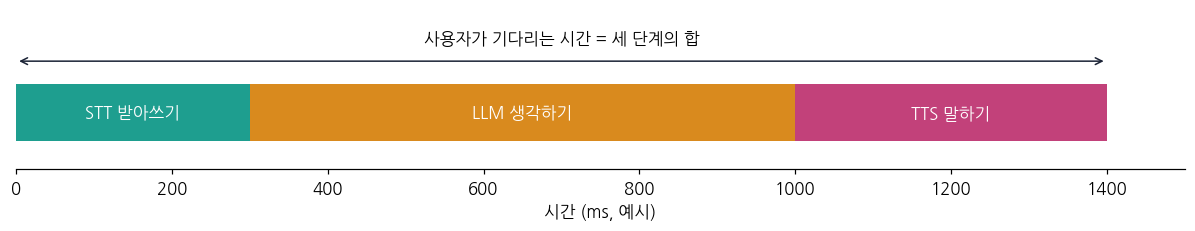

오늘 만든 비서는 앞 단계가 **끝나야** 다음 단계가 시작됩니다. 그래서 사용자가 기다리는 시간은 세 단계 시간의 **합**입니다. 아래 결과에서 어느 단계가 가장 오래 걸리는지 확인해 보세요.

In [ ]:
async def voice_agent(input_wav: str):
    timings = {}
    # 1) STT
    user_text, _, _, timings["STT"] = transcribe(input_wav)
    print(f"🧑 사용자: {user_text}")
    # 2) LLM
    reply, timings["LLM"] = llm_reply(user_text)
    print(f"🤖 비서  : {reply}")
    # 3) TTS
    t0 = time.perf_counter()
    out = await tts(reply, "agent_reply.wav")
    timings["TTS"] = time.perf_counter() - t0
    display(Audio(out, autoplay=True))

    total = sum(timings.values())
    for k, v in timings.items():
        print(f"  {k:4s}: {v*1000:7.0f} ms")
    print(f"  합계: {total*1000:7.0f} ms")

    plt.figure(figsize=(8, 1.8))
    left = 0
    colors = {"STT": "#1E9E8F", "LLM": "#E8A33D", "TTS": "#C2417A"}
    for k, v in timings.items():
        plt.barh(0, v * 1000, left=left, color=colors[k], label=k)
        left += v * 1000
    plt.axvline(1000, ls="--", c="gray"); plt.text(1005, 0.3, "1s target", color="gray")
    plt.yticks([]); plt.xlabel("Latency (ms)"); plt.legend(loc="upper right", ncol=3)
    plt.tight_layout(); plt.show()
    return timings

# 질문 음성을 TTS로 만들어 입력 (마이크 녹음 파일로 바꿔도 됩니다)
q_wav = await tts("음성 인식과 음성 합성의 차이를 짧게 설명해 줘.", "question.wav", voice="ko-KR-InJoonNeural")
timings = await voice_agent(q_wav)

In [ ]:
# 🎙️ 내 목소리로 질문하기: 녹음 후 바로 에이전트 실행
try:
    q = record_audio(5, "my_question.wav")
    await voice_agent(q)
except Exception as e:
    print("⚠️ 녹음 불가:", e)

### 💡 더 빠른 비서를 만들려면?
- 사람끼리 대화할 때는 상대가 말을 끝낸 뒤 **약 0.2초** 만에 대답이 시작됩니다.
- 실전 음성 비서는 앞 단계가 끝나기 전에 **조금씩 먼저 넘겨서**(Streaming) 첫 소리가 나오는 시간을 줄입니다. 6주차에 Pipecat, LiveKit으로 만들어 봅니다.
- **Speech-to-Speech** 모델은 글자로 바꾸는 단계 자체를 없애 더 빠르게 대답합니다.

### 🧩 빈칸 실습 6: 나만의 음성 비서 조립하기
위 그림의 순서대로 **함수 이름 3개**를 채우세요.

In [ ]:
# 🧩 빈칸 실습 6
async def my_agent(input_wav):
    user_text = ____(input_wav)[0]              # ① 듣기: 음성 → 글자
    reply, _  = ____(user_text)                 # ② 생각하기: 글자 → 답변
    out = await ____(reply, "my_agent.wav")     # ③ 말하기: 답변 → 음성
    return user_text, reply, out

u, r, o = await my_agent(q_wav)
print(f"🧑 사용자: {u}\n🤖 비서  : {r}")
display(Audio(o))
check(bool(u) and bool(r), hint="① transcribe ② llm_reply ③ tts 순서입니다.")

<details>
<summary><b>🔑 정답 및 해설 보기 (클릭)</b></summary>

```python
async def my_agent(input_wav):
    user_text = transcribe(input_wav)[0]
    reply, _  = llm_reply(user_text)
    out = await tts(reply, "my_agent.wav")
    return user_text, reply, out
```

**해설**
- `transcribe()`는 결과 4개를 돌려주므로 `[0]`으로 첫 번째인 **글자**만 꺼냅니다.
- `tts()`는 인터넷으로 음성을 받아오는 함수라 앞에 `await`를 붙입니다.
- 내 목소리로 해보려면 마지막 줄의 `q_wav` 대신 `record_audio(5, "my_q.wav")`의 결과를 넣으면 됩니다.

</details>

## Part 7. 정리 & 과제

### 오늘 배운 것
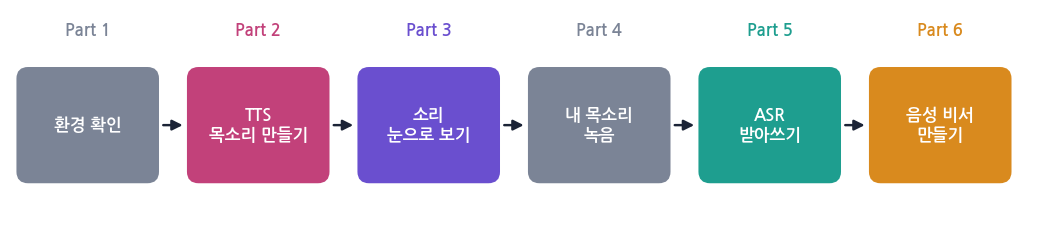

| 개념 | 핵심 |
|---|---|
| ASR / TTS | 소리 → 글자 / 글자 → 소리 |
| 16kHz mono WAV | 음성 모델의 공통 입력 형식, ffmpeg로 변환 |
| 파형 / 스펙트로그램 | 소리의 크기 / 언제 어떤 높낮이의 소리가 났는가 |
| RTF | 음성 길이 대비 처리 시간, 1보다 작으면 실시간보다 빠름 |
| CER | 틀린 글자 비율, 낮을수록 정확 |
| 음성 비서 | 듣기(STT) → 생각하기(LLM) → 말하기(TTS) |

### 📝 과제
1. 아래 셀을 실행해 `small`, `medium`, `large-v3-turbo` 세 모델의 **CER과 처리 시간**을 비교하고, 어떤 상황에 어떤 모델을 쓰면 좋을지 한두 문장으로 적어 보세요.
2. `SYSTEM_PROMPT`를 바꿔 나만의 음성 비서 캐릭터(예: 영어 회화 선생님)를 만들어 보세요.
3. 로컬 PC에 `uv`로 개발환경을 구성하고 `torch.cuda.is_available()` 결과 화면을 캡처해 제출하세요.

### ✅ 이해도 확인
오늘 내용을 워크시트로 점검합니다. 객관식, 선 잇기, 순서 맞추기, O/X, 계산 등 15문항입니다.

> 📝 **[D1 이해도 확인 워크시트 열기](https://imguru-mooc.github.io/AI_Voice/day01/worksheet.html)** — 이름과 소속을 입력하고 풀어 보세요. 채점 후 **인쇄 / PDF 저장** 버튼으로 결과를 제출할 수 있습니다.
>
> 🎬 복습용: [애니메이션 전체 보기](https://imguru-mooc.github.io/AI_Voice/day01/animation.html)

In [ ]:
# (과제 1 템플릿) 모델 크기별 비교
import pandas as pd

audio = load_16k("sample.wav")      # 경로 대신 numpy 배열 사용 (PyAV 충돌 회피), 한 번만 로드

results = []
for size in ["small", "medium", "large-v3-turbo"]:
    m = WhisperModel(size, device=DEVICE, compute_type=COMPUTE_TYPE)
    t0 = time.perf_counter()
    segs, info = m.transcribe(audio, language="ko", beam_size=5)
    hyp = " ".join(s.text.strip() for s in segs)   # generator 소비 시점에 실제 추론 → 시간 측정에 포함
    el = time.perf_counter() - t0
    results.append({"model": size, "CER": jiwer.cer(normalize_ko(SAMPLE_TEXT), normalize_ko(hyp)),
                    "time(s)": round(el, 2), "RTF": round(el / info.duration, 3), "hyp": hyp})
    del m
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

pd.DataFrame(results)